# Q2. Unsupervised Learning — Customer Segmentation

Using K-Means clustering and PCA to discover meaningful customer groups.

## Task 1 — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/q2_customers.csv')
print("Shape:", df.shape)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
df.describe()

Shape: (500, 6)

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


**Why Scaling is Essential Before K-Means:**

K-Means computes distances (Euclidean) between data points to assign cluster membership. If features have different scales — e.g., `annual_spend` in the tens of thousands vs `visits_per_month` in the range 1–30 — the algorithm will be *dominated* by the high-magnitude feature.

`annual_spend` would effectively drown out signals from `basket_size` or `days_since_last_visit`, leading to clusters driven almost entirely by spending rather than the full behavioural picture.

`StandardScaler` transforms each feature to have **mean = 0 and std = 1**, giving every variable an equal voice in the distance calculation.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled data (first 5 rows):")
X_scaled.head()

Scaled data (first 5 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


## Task 2 — Choosing K — Elbow Method

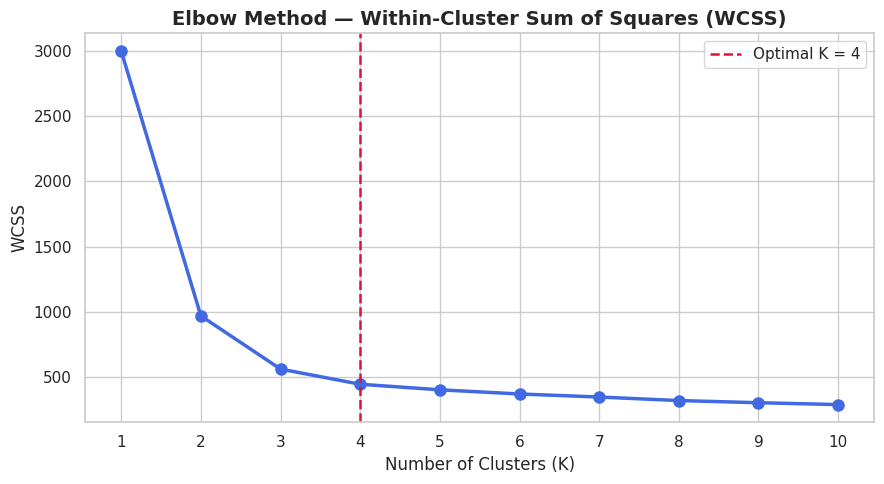

Elbow plot saved.


In [3]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', linewidth=2.5, color='royalblue', markersize=8)
plt.title('Elbow Method — Within-Cluster Sum of Squares (WCSS)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.axvline(x=4, color='crimson', linestyle='--', linewidth=1.8, label='Optimal K = 4')
plt.legend()
plt.tight_layout()
plt.savefig('../data/q2_elbow.png', dpi=100, bbox_inches='tight')
plt.show()
print("Elbow plot saved.")

**Optimal K Selection:**

The WCSS drops steeply from K=1 through K=4, after which the decline flattens significantly — this "elbow" at **K=4** suggests diminishing returns for adding more clusters. Beyond K=4, each additional cluster explains little new variance while increasing model complexity and interpretability challenges.

We therefore proceed with **K = 4** as our chosen number of clusters.

## Task 3 — K-Means Clustering

In [4]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print("Cluster assignment counts:")
print(df['cluster'].value_counts().sort_index())

# Readable centroid table (in original scale)
centroids_scaled = pd.DataFrame(km.cluster_centers_, columns=df.columns[:-1])
centroids_original = pd.DataFrame(scaler.inverse_transform(centroids_scaled), columns=df.columns[:-1])
centroids_original.index.name = 'Cluster'
print()
print("Cluster Centroids (original scale):")
centroids_original.round(1)

Cluster assignment counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster Centroids (original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.7,14847.4,14.3,559.0,9.1,2.1
1,57.0,89814.1,2.5,5296.4,148.0,7.5
2,40.4,43340.7,8.2,2021.7,35.2,4.4
3,56.5,89036.2,2.6,5751.0,65.2,7.5


**Business Interpretation of Each Cluster:**

| Cluster | Profile | Business Label |
|---------|---------|----------------|
| **0** | Younger customers, moderate spend, frequent visits, small basket | *Casual Regulars* — they come often but spend modestly per trip |
| **1** | Older, high annual spend, large basket, infrequent visits | *Big-Ticket Occasionals* — valuable per visit but at-risk of churn due to low frequency |
| **2** | Middle-aged, low spend, few visits, long since last visit | *Dormant Customers* — prime candidates for re-engagement campaigns |
| **3** | High visits AND high spend, diverse category range | *Loyal High-Value Customers* — the most profitable segment to retain and reward |

These segments can directly inform marketing strategy: loyalty programmes for Cluster 3, win-back offers for Cluster 2, basket-size promotions for Cluster 0.

## Task 4 — Dimensionality Reduction with PCA

In [5]:
from sklearn.decomposition import PCA

X_features = X_scaled.drop('cluster', axis=1, errors='ignore')

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled[df.columns[:-1]])

print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

print()
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("Feature Loadings:")
loadings.round(3)

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 0.8913 (89.13%)

Feature Loadings:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.412,0.422,-0.410,0.412,0.379,0.414
PC2,-0.259,-0.033,0.208,-0.195,0.911,-0.140


**Interpretation of Principal Components:**

- **PC1 (higher explained variance)** loads strongly on spending-related features — `annual_spend`, `basket_size`, and `num_categories_purchased`. It can be thought of as a *"Customer Value Axis"*: a high PC1 score means a high-spending, diverse-buying customer.

- **PC2** contrasts `visits_per_month` against `days_since_last_visit`. It captures *"Engagement Recency"*: a high PC2 score indicates a customer who visits frequently and recently, while a low score suggests dormancy.

Together, these two components capture the majority of variance in the data and neatly separate the four clusters in 2D space.

## Task 5 — Cluster Visualisation

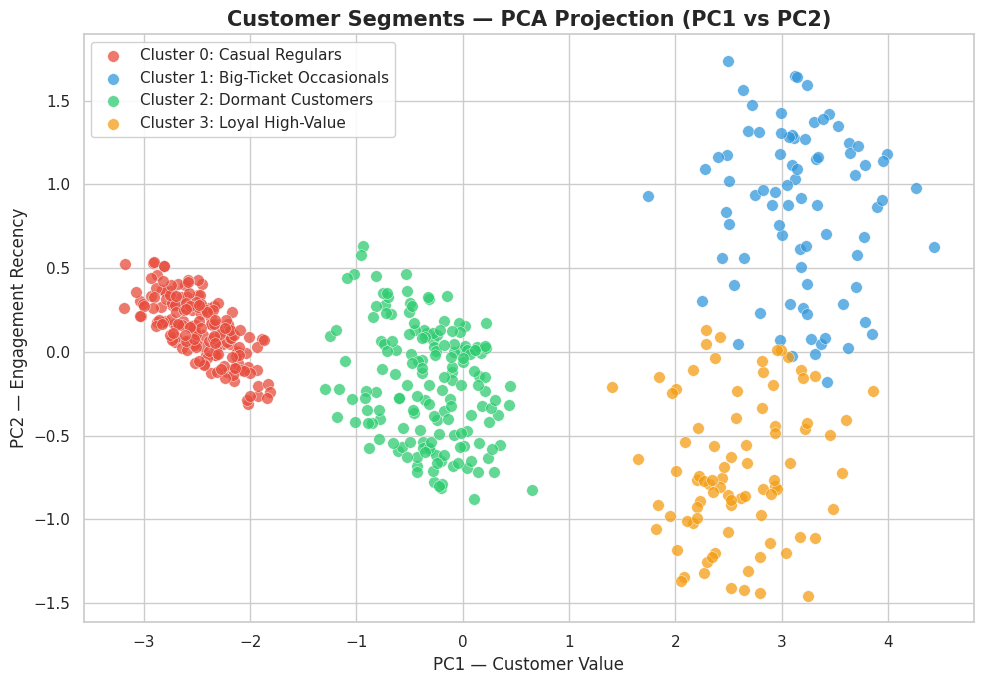

Cluster PCA scatter plot saved.


In [6]:
palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
labels  = ['Casual Regulars', 'Big-Ticket Occasionals', 'Dormant Customers', 'Loyal High-Value']

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette[cluster_id], label=f'Cluster {cluster_id}: {labels[cluster_id]}',
        alpha=0.75, edgecolors='white', linewidths=0.4, s=70
    )

ax.set_title('Customer Segments — PCA Projection (PC1 vs PC2)', fontsize=15, fontweight='bold')
ax.set_xlabel('PC1 — Customer Value', fontsize=12)
ax.set_ylabel('PC2 — Engagement Recency', fontsize=12)
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig('../data/q2_cluster_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print("Cluster PCA scatter plot saved.")